In [1]:
import catalogue_analysis as ca
import numpy as np
from astropy.table import join,Table,Column,vstack,setdiff
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from scipy import stats, interpolate, ndimage
import sys

In [2]:
readtractorfiles = False
fibrecut= True

In [3]:
if readtractorfiles:
    # From a whole set of Tractor files I want to extract ra,dec,flux_r,mw_transmission_r,psf_depth_r,gaL_depth_r,shape_r,shape_e1,shape_e2 and concaternate to produce a single deep catalog

    i=0
    with open("./filelist.txt", "r") as f:
      for line in f:
        filename = line.strip()  # remove newline and whitespace
        i+=1
        if not filename:
            continue

        # do something with filename
        print(i,f"Processing {filename}")
        dat=Table.read(filename) 

        smdat=dat[["ra", "dec", "flux_r", "fiberflux_r", "mw_transmission_r", "psfdepth_r", "galdepth_r", "shape_r", "shape_e1", "shape_e2", "type"]].copy()  
        del dat
        if (i==1):
            alldat=smdat
        else:
            alldat=vstack([alldat,smdat])

    alldat.info('stats')  

    # Write the combined table to a fits file
    alldat.write("sdata/cosmos.fits", format="fits", overwrite=True)

In [4]:
cosmos=Table.read("sdata/cosmos.fits")
cosmos['rmag']=cosmos['flux_r'].copy() # initialise
mask=(cosmos['flux_r'].value>0.0)
cosmos['rmag'][mask]=22.5-2.5*np.log10(cosmos['flux_r'][mask].value)
cosmos['rmag'][~mask]=30.0 #default value that will result in them being thrown away
cosmos.info('stats')

<Table length=6734319>
       name           mean        std       min        max    
----------------- ------------ --------- --------- -----------
               ra        150.2   1.61844    145.85     154.476
              dec      2.20857   1.66774  -1.10087     5.86454
           flux_r      25.8193   9240.96  -23056.3 1.61362e+07
      fiberflux_r      14.2853   1106.46         0 1.16364e+06
mw_transmission_r     0.936005 0.0323247  0.643303    0.971159
       psfdepth_r      5893.62   6830.11         0     26163.7
       galdepth_r      3213.86   3753.89         0     14609.1
          shape_r     0.362991    0.5495         0      72.782
         shape_e1  0.000415874  0.113894 -0.997965    0.988826
         shape_e2 -0.000197719  0.114109 -0.986161    0.982636
             type           --        --        --          --
             rmag      24.1296   1.89359    4.4805     39.8153


In [5]:
if readtractorfiles:
    # From a whole set of DR9 Tractor files I want to extract ra,dec,flux_r,mw_transmission_r,psf_depth_r,gaL_depth_r,shape_r,shape_e1,shape_e2 and concaternate to produce a single deep catalog

    i=0
    with open("./filelist.txt", "r") as f:
      for line in f:
        filename = line.strip()  # remove newline and whitespace
        i+=1
        if not filename:
            continue

        # do something with filename
        lsfilename='/global/cfs/cdirs/desi/external/legacysurvey/dr9/south/tractor' + filename[-26:]
        print(i,f"Processing {lsfilename}")
        dat=Table.read(lsfilename) 

        smdat=dat[["ra", "dec", "flux_r","fiberflux_r", "mw_transmission_r", "psfdepth_r", "galdepth_r", "shape_r", "shape_e1", "shape_e2", "type"]].copy()
        del dat
        if (i==1):
            alldat=smdat
        else:
            alldat=vstack([alldat,smdat])

    alldat.info('stats')  

    # Write the combined table to a fits file
    alldat.write("sdata/LSdr9.fits", format="fits", overwrite=True)


In [6]:
target=Table.read("sdata/LSdr9.fits")
target['rmag']=target['flux_r'].copy() # initialise
mask=(target['flux_r'].value>0.0)
if fibrecut: # Also remove objects that don't make the BGS fibre magnitude cut
    fibrermag=22.5-2.5*np.log10(target['fiberflux_r'].value/target['mw_transmission_r'].value)
    rmag=22.5-2.5*np.log10(target['flux_r'].value/target['mw_transmission_r'].value)
    reject = fibrermag > 22.9 + (rmag-17.8)
    reject = reject | (fibrermag >22.9)
    mask = mask & ~reject

target['rmag'][mask]=22.5-2.5*np.log10(target['flux_r'][mask].value)
target['rmag'][~mask]=30.0 #default value that will result in them being thrown away
target.info('stats')

/tmp/ipykernel_1429163/529441848.py:5: RuntimeWarning: divide by zero encountered in log10
  fibrermag=22.5-2.5*np.log10(target['fiberflux_r'].value/target['mw_transmission_r'].value)
/tmp/ipykernel_1429163/529441848.py:6: RuntimeWarning: divide by zero encountered in log10
  rmag=22.5-2.5*np.log10(target['flux_r'].value/target['mw_transmission_r'].value)
/tmp/ipykernel_1429163/529441848.py:6: RuntimeWarning: invalid value encountered in log10
  rmag=22.5-2.5*np.log10(target['flux_r'].value/target['mw_transmission_r'].value)


<Table length=4232958>
       name          mean       std       min        max    
----------------- ---------- --------- --------- -----------
               ra    150.043    2.1742   145.745     154.506
              dec    2.26046   1.89692  -1.13067     5.88099
           flux_r    41.6135     11209  -2546.79 1.61362e+07
      fiberflux_r    24.2436   1109.81         0      774182
mw_transmission_r   0.922944 0.0455776  0.643304    0.971159
       psfdepth_r    642.959   196.904         0     1420.05
       galdepth_r    367.651   111.439         0      872.74
          shape_r   0.369772   0.52511         0      72.782
         shape_e1 0.00024647  0.100893 -0.997963    0.948603
         shape_e2 0.00027827  0.100234 -0.927786    0.949787
             type         --        --        --          --
             rmag    28.0116   3.87788   7.37371          30


In [7]:
UseTractor = True
if UseTractor:
    flux_r="flux_r"
    ra="ra"
    dec="dec"
    galdepth_r="galdepth_r"
else:
    # Read
    #DR9 BGS-Bright Target catalogue
    tpath='/global/cfs/cdirs/desi/survey/catalogs/main/LSS/BGS_BRIGHTtargetsDR9v1.1.1.fits'  
    target=Table.read(tpath)
    target.info('stats')
    flux_r="FLUX_R"
    ra="RA"
    dec="DEC"
    galdepth_r="GALDEPTH_R"

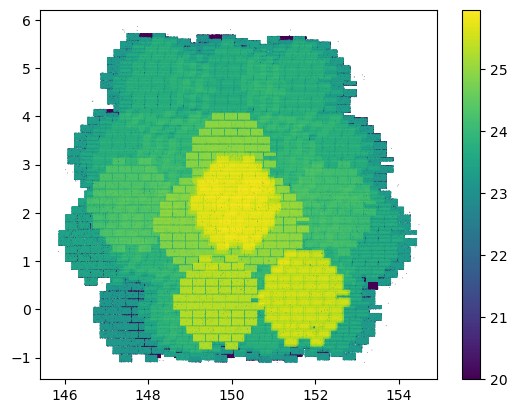

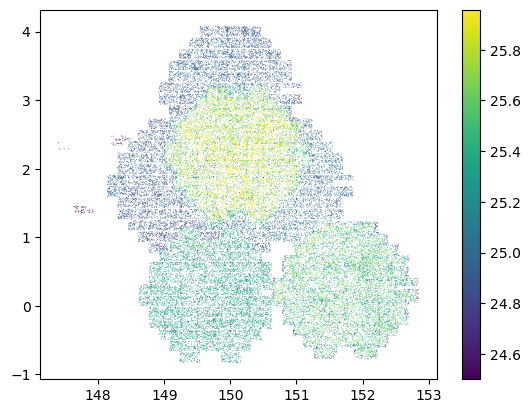

<Table length=49939>
       name           mean      std       min      max   
----------------- ----------- -------- --------- --------
               ra     150.309  1.06349   147.396  152.853
              dec     1.36511  1.24367 -0.827799  4.07515
           flux_r     74.1292  144.804   10.0001  6694.93
      fiberflux_r     45.8924  90.9763         0  1216.84
mw_transmission_r    0.946116 0.013602   0.81637 0.968988
       psfdepth_r     9757.58  5688.77   1458.63  26163.7
       galdepth_r     5283.16  3147.57   995.339  14609.1
          shape_r    0.773617  1.41338         0   27.248
         shape_e1 0.000593461 0.146222 -0.980699 0.974184
         shape_e2 0.000453574 0.147026 -0.925795 0.878256
             type          --       --        --       --
             rmag     18.6312  1.16247   12.9356       20
            depth     25.3089 0.330719      24.5  25.9584


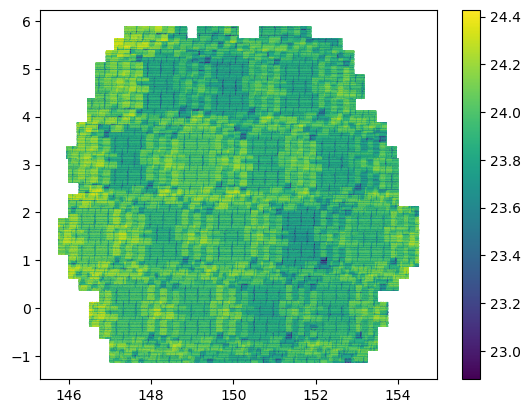

<Table length=200871>
       name           mean       std       min        max    
----------------- ----------- --------- --------- -----------
               ra     149.999   2.15686   145.747     154.503
              dec     2.19524   1.90321  -1.13037     5.87973
           flux_r     680.181   7089.93   10.0001 1.12335e+06
      fiberflux_r     501.118   5071.16  0.569335      774182
mw_transmission_r    0.922084 0.0461746  0.646049    0.971159
       psfdepth_r     576.281   241.721         0     1420.05
       galdepth_r     330.359   137.025         0     862.942
          shape_r    0.634156   1.23431         0     55.4192
         shape_e1 0.000258842  0.134513 -0.988617    0.926982
         shape_e2 9.80415e-05  0.134788 -0.923432    0.926094
             type          --        --        --          --
             rmag     18.1661   1.79345   7.37371          20
            depth     23.8484  0.285768   22.8809     24.4226


In [8]:
# Compute depth parameters and apply cuts to the catalogues that will be matched

cosmos['depth']=cosmos['galdepth_r'] #initialise
mask = (cosmos['galdepth_r']>0)
cosmos['depth'][mask]=22.5-2.5*np.log10(5.0/np.sqrt(cosmos['galdepth_r'][mask]))
cosmos['depth'][~mask]=20.0 # default value that will result in them being thrown away

# Depth of matched objects direct
plt.scatter(cosmos['ra'],cosmos['dec'],c=cosmos["depth"],cmap='viridis',s=1.0, marker='.', linewidths=0)
plt.colorbar() 
plt.show()

# Depth of matched objects direct
mask= (cosmos["depth"]>24.5) & (cosmos["rmag"]<20.0)
plt.scatter(cosmos['ra'][mask],cosmos['dec'][mask],c=cosmos["depth"][mask],cmap='viridis',s=1.0, marker='.', linewidths=0)
plt.colorbar() 
plt.show()


cosmos=cosmos[mask].copy()
cosmos.info('stats')

target['depth']=target[galdepth_r] #initialise
mask = (target[galdepth_r]>0) 
target['depth'][mask]=22.5-2.5*np.log10(5.0/np.sqrt(target['galdepth_r'][mask]))
target['depth'][~mask]=23.0 # default value that will result in them being thrown away

# Depth LS DR9 objects 
plt.scatter(target['ra'],target['dec'],c=target["depth"],cmap='viridis',s=1.0, marker='.', linewidths=0)
plt.colorbar() 
plt.show()

mask= (target['rmag']<20.0)

target=target[mask].copy()
target.info('stats')



In [9]:
#Compute magnitudes and cosmos SB
#Throw away stars ??
star=(cosmos["type"]=="PSF")
cosmos=cosmos[~star].copy()

if fibrecut:
    #Throw away objects not making BGS fibre magnitude cut
    fibrermag_cos=22.5-2.5*np.log10(cosmos['fiberflux_r'].value/cosmos['mw_transmission_r'].value)
    rmag_cos=22.5-2.5*np.log10(cosmos['flux_r'].value/cosmos['mw_transmission_r'].value)
    reject = fibrermag_cos > 22.9 + (rmag_cos-17.8)
    reject = reject | (fibrermag_cos >22.9)
    cosmos=cosmos[~reject].copy()


#replace by non extinction corrected magnitude
rmag_cos=22.5-2.5*np.log10(cosmos[flux_r].value)
epsilon=np.sqrt(cosmos['shape_e1'].value**2+cosmos['shape_e2'].value**2)
b_a=(1-epsilon)/(1+epsilon)
SB_cos=rmag_cos*0.0+20.0 #intialize with default value
mask= (cosmos['shape_r']>0)
SB_cos[mask]=rmag_cos[mask]+2.5*np.log10(2.0*np.pi*(cosmos['shape_r'][mask].value**2)*b_a[mask])

#target.info('stats')
#rmag=22.5-2.5*np.log10(target['FLUX_R'].value/target['MW_TRANSMISSION_R'].value)
rmag=22.5-2.5*np.log10(target['flux_r'].value)

In [10]:
# Convert to SkyCoord
if UseTractor:
    coords_target = SkyCoord(ra=target[ra], dec=target[dec])
else:
    coords_target = SkyCoord(ra=target[ra]*u.deg, dec=target[dec]*u.deg)
print('Target coords set up')

coords_cosmos = SkyCoord(ra=cosmos['ra'], dec=cosmos['dec'])
print('Cosmo coords set up')

# Match each object in cosmos to the nearest in the target and lss table 
idx_tar, sep2d_tar, _ = coords_cosmos.match_to_catalog_sky(coords_target)



Target coords set up
Cosmo coords set up


Maximum separation of matches to BGS target catalogue s= 0d01m44.97123312s


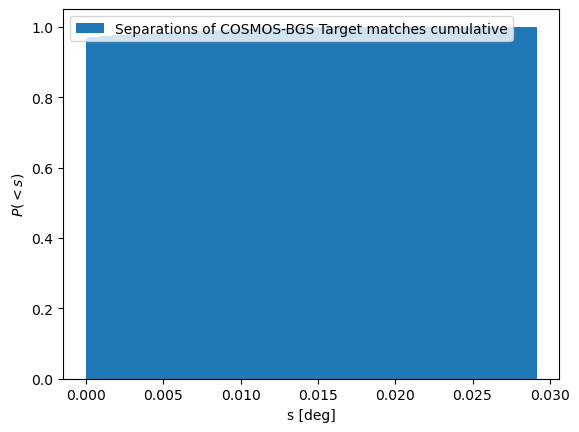

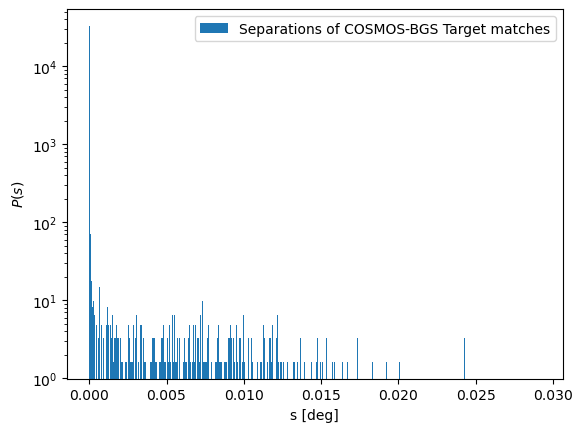

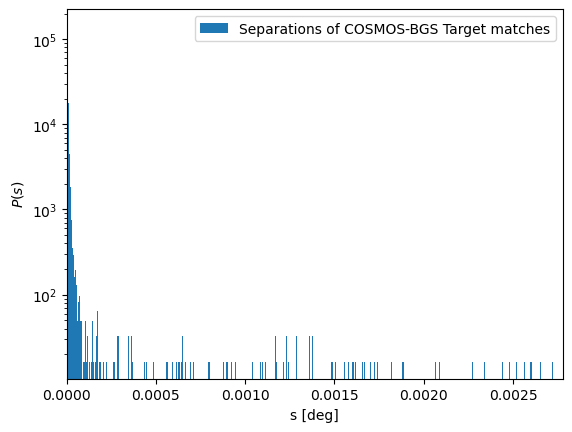

In [11]:

#
print('Maximum separation of matches to BGS target catalogue s=',max(sep2d_tar))

#Plot histogram of separation of matches
plt.xlabel('s [deg]')
plt.ylabel('$P(<s)$')
plt.hist(sep2d_tar,bins=1000,density=True,cumulative=True,label='Separations of COSMOS-BGS Target matches cumulative')
#plt.xlim([0,55.0])
#plt.ylim([0.0,15000])
plt.legend()
plt.show()


plt.xlabel('s [deg]')
plt.ylabel('$P(s)$')
plt.hist(sep2d_tar,bins=1000,density=True,cumulative=False,label='Separations of COSMOS-BGS Target matches')
#plt.xlim([0,813.0])
plt.yscale('log')
#plt.ylim([0.0,0.1])
plt.legend()
plt.show()



plt.xlabel('s [deg]')
plt.ylabel('$P(s)$')
plt.hist(sep2d_tar,bins=10000,density=True,cumulative=False,label='Separations of COSMOS-BGS Target matches')
plt.xlim([0,10.0/3600.0])
plt.yscale('log')
#plt.ylim([0.0,0.1])
plt.legend()
plt.show()


In [12]:
matched = (sep2d_tar.value<1.5/3600.0) # deem matched if within 1.5 arc sec

In [13]:
print(matched.sum(),len(matched),'Matched Fraction:',(matched.sum()/len(matched)))

20533 21161 Matched Fraction: 0.9703227635745003


In [14]:
def make_median_interpolator(
    x, y, z,
    nx=50, ny=50,
    x_range=None, y_range=None,
    fill_strategy='nearest',   # 'nearest' or None
    smooth_sigma=None          # e.g., 0.5–1.5 (in grid cells) for optional smoothing
):
    """
    Build a callable f(x, y) returning the median z in (x,y) bins, interpolated
    across the domain of the data.

    Parameters
    ----------
    x, y, z : array-like, shape (n,)
        Scattered data points.
    nx, ny : int
        Number of bins along x and y.
    x_range, y_range : (min, max) or None
        Domain to bin. If None, inferred from data min/max.
    fill_strategy : {'nearest', None}
        How to fill empty bins (NaN medians). 'nearest' fills from nearest
        non-empty bin; None leaves as NaN (interpolator then returns NaN there).
    smooth_sigma : float or None
        Optional Gaussian smoothing (in grid-cell units) applied to the median grid
        after filling. Use a small value like 0.8–1.2 to reduce blockiness.

    Returns
    -------
    f : callable
        f(query_xy) → z, where query_xy is an array of shape (m, 2) with columns (x, y).
        Returns NaN outside the [x_range, y_range].
    grid : dict
        Contains 'x_edges', 'y_edges', 'x_centers', 'y_centers', 'median_grid' (filled/smoothed).
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)

    # Drop rows with any NaN
    mask = ~(np.isnan(x) | np.isnan(y) | np.isnan(z))
    x, y, z = x[mask], y[mask], z[mask]

    if x_range is None:
        x_range = (np.min(x), np.max(x))
    if y_range is None:
        y_range = (np.min(y), np.max(y))

    # Define bin edges (uniform)
    x_edges = np.linspace(x_range[0], x_range[1], nx + 1)
    y_edges = np.linspace(y_range[0], y_range[1], ny + 1)

    # Compute 2D binned median
    # Note: 'median' is supported by scipy>=1.10; for older versions, use statistic=lambda v: np.nanmedian(v)
    stat, x_edges_out, y_edges_out, _ = stats.binned_statistic_2d(
        x, y, z, statistic='median', bins=[x_edges, y_edges]
    )

    # Centers for interpolation grid
    x_centers = 0.5 * (x_edges_out[:-1] + x_edges_out[1:])
    y_centers = 0.5 * (y_edges_out[:-1] + y_edges_out[1:])

    median_grid = stat  # shape (nx, ny) but may contain NaNs where bins were empty

    # Fill empty bins if requested
    if fill_strategy == 'nearest':
        XI, YI = np.meshgrid(x_centers, y_centers, indexing='ij')  # (nx, ny)
        pts_all = np.column_stack([XI.ravel(), YI.ravel()])
        vals = median_grid.ravel()
        good = ~np.isnan(vals)
        if np.any(good):
            # nearest neighbor fill on the grid
            filled_vals = interpolate.griddata(
                pts_all[good], vals[good], pts_all, method='nearest'
            )
            median_grid = filled_vals.reshape(median_grid.shape)
        # If all bins were NaN (pathological), we leave as all NaN.

    # Optional smoothing to reduce blockiness
    if smooth_sigma is not None and smooth_sigma > 0 and np.any(~np.isnan(median_grid)):
        # For safety, work on a copy with NaNs replaced by local means via nearest fill
        mg = median_grid.copy()
        if np.any(np.isnan(mg)):
            XI, YI = np.meshgrid(x_centers, y_centers, indexing='ij')
            pts_all = np.column_stack([XI.ravel(), YI.ravel()])
            vals = mg.ravel()
            good = ~np.isnan(vals)
            if np.any(good):
                mg = interpolate.griddata(
                    pts_all[good], vals[good], pts_all, method='nearest'
                ).reshape(mg.shape)
        median_grid = ndimage.gaussian_filter(mg, sigma=smooth_sigma, mode='nearest')

    # Build linear interpolator over the centers grid
    interpolator = interpolate.RegularGridInterpolator(
        (x_centers, y_centers), median_grid,
        method='linear', bounds_error=False, fill_value=np.nan
    )

    def f(query_xy):
        """
        Vectorized evaluator.
        query_xy: array-like of shape (m, 2) with columns [x, y].
        Returns: array shape (m,) of median z estimates (NaN outside domain).
        """
        q = np.asarray(query_xy)
        return interpolator(q)

    grid = {
        'x_edges': x_edges_out,
        'y_edges': y_edges_out,
        'x_centers': x_centers,
        'y_centers': y_centers,
        'median_grid': median_grid
    }
    return f, grid


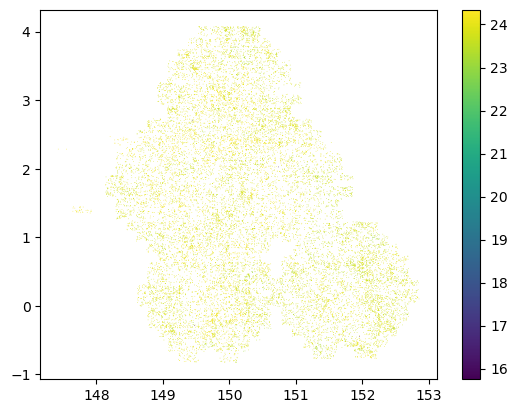

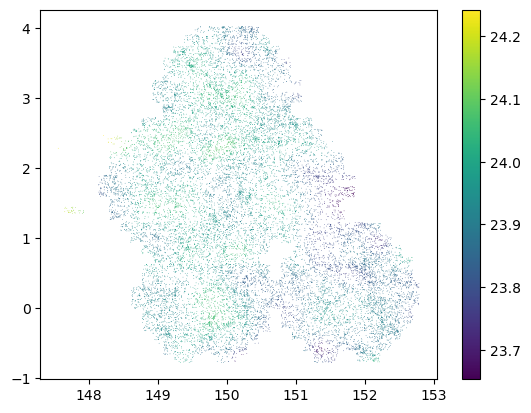

In [15]:


depth_mag=22.5-2.5*np.log10(5.0/np.sqrt(0.0001+target[galdepth_r][idx_tar][matched])) ## Needs the right relation between GALDEPTH and limiting magnitude



#Set up a look-up table for the depth as function of RA and DEC
f, grid = make_median_interpolator(cosmos['ra'][matched],cosmos['dec'][matched],depth_mag,
    nx=50, ny=50,           # resolution of the (x,y) bins
    fill_strategy='nearest',# fill empty bins from nearest neighbors
    smooth_sigma=1.0        # optional smoothing to reduce blockiness
)

# Evaluate depth at new query points:
depth = f(np.column_stack([cosmos['ra'], cosmos['dec']]))  # returns median estimates at those locations



# Depth of matched objects direct
plt.scatter(cosmos['ra'][matched],cosmos['dec'][matched],c=depth_mag,cmap='viridis',s=1.0, marker='.', linewidths=0)
plt.colorbar() 
plt.show()

# Depth of matched objects from spatial look-up
plt.scatter(cosmos['ra'][matched],cosmos['dec'][matched],c=depth[matched],cmap='viridis',s=1.0, marker='.', linewidths=0)
plt.colorbar() 
plt.show()


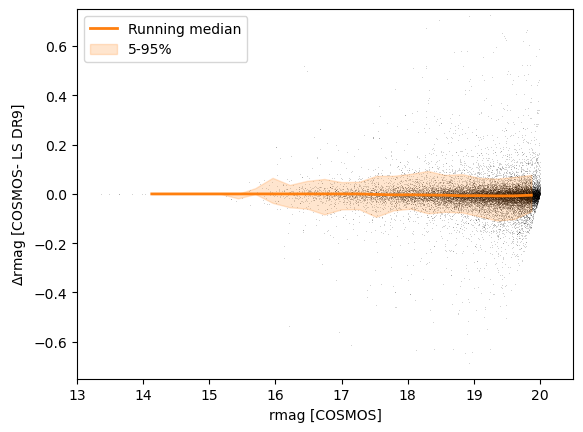

[14.13043478 14.39130435 14.65217391 14.91304348 15.17391304 15.43478261
 15.69565217 15.95652174 16.2173913  16.47826087 16.73913043 17.
 17.26086957 17.52173913 17.7826087  18.04347826 18.30434783 18.56521739
 18.82608696 19.08695652 19.34782609 19.60869565 19.86956522] [ 0.          0.          0.          0.          0.         -0.01807947
 -0.00043564 -0.03615303 -0.05439053 -0.05947542 -0.08312197 -0.06261253
 -0.06147289 -0.09296989 -0.06701775 -0.05987244 -0.07875862 -0.07259941
 -0.07562447 -0.09114075 -0.10787621 -0.10219154 -0.07042046] [0.         0.         0.         0.         0.         0.
 0.02342587 0.0652422  0.03660603 0.05288334 0.06067362 0.0480114
 0.04913855 0.07292604 0.07351074 0.08127651 0.0931942  0.07701797
 0.08041    0.06489563 0.06206741 0.06873932 0.07717094] [0.         0.         0.         0.         0.         0.00903974
 0.01193075 0.05069761 0.04549828 0.05617938 0.07189779 0.05531197
 0.05530572 0.08294797 0.07026424 0.07057447 0.08597641 0.07480

In [16]:
#Compare magnitudes of the matched objects

# 2) Define bins along M_r (choose width or number of bins)
xmin, xmax = 14, 20.0
nbins = 23                      # e.g., 22 bins => ~0.5 mag each
edges = np.linspace(xmin, xmax, nbins+1)
centers = 0.5*(edges[:-1] + edges[1:])

# 3) Compute quantiles per bin
def binned_quantiles(x, y, edges, qs=(0.5, 0.16, 0.84)):
    # qs are quantiles (0.5=median, 0.16/0.84 ~ ±1σ for normal)
    qvals = np.full((len(qs), len(edges)-1), np.nan)
    counts = np.zeros(len(edges)-1, dtype=int)
    for i in range(len(edges)-1):
        m = (x >= edges[i]) & (x < edges[i+1])
        counts[i] = m.sum()
        if counts[i] > 0:
            qvals[:, i] = np.quantile(y[m], qs)
    return qvals, counts

qs = (0.5, 0.05, 0.95)  # median and chosen percentiles
qvals, counts = binned_quantiles(rmag_cos[matched],rmag_cos[matched]-rmag[idx_tar][matched], edges, qs=qs)

median = qvals[0]
p16 = qvals[1]
p84 = qvals[2]

# 4) Plot: scatter + median + percentile band
#fig, ax = plt.subplots(figsize=(6,4.5), dpi=120)
#plt.scatter(dat['ABSMAG_RP1'], SB, marker=',', lw=0, s=1.0, alpha=1.0, label='Sample')



plt.scatter(rmag_cos[matched],rmag_cos[matched]-rmag[idx_tar][matched],color='black',s=0.25, marker='.', linewidths=0)
plt.plot(centers, median, color='C1', lw=2, label='Running median')
plt.fill_between(centers, p16, p84, color='C1', alpha=0.2, label='5-95%')
plt.ylim([-0.75,0.75])
plt.xlim([13,20.5])
plt.ylabel('$\Delta$rmag [COSMOS- LS DR9]')
plt.xlabel('rmag [COSMOS]')
plt.legend()
plt.show()

print( centers, p16, p84, (p84-p16)/2.0)

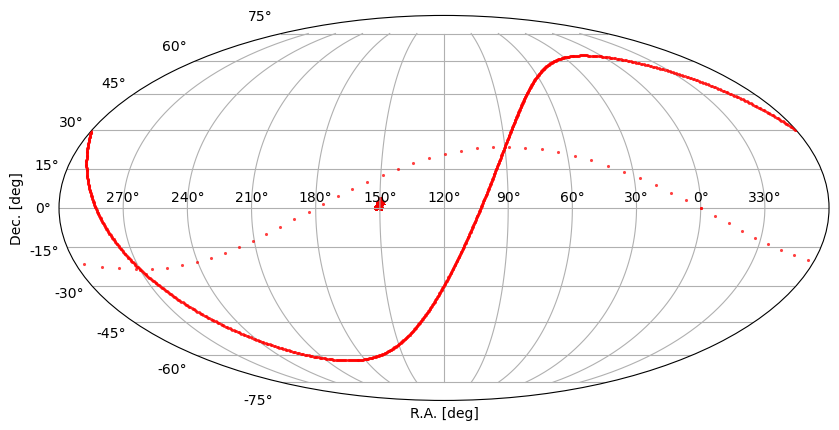

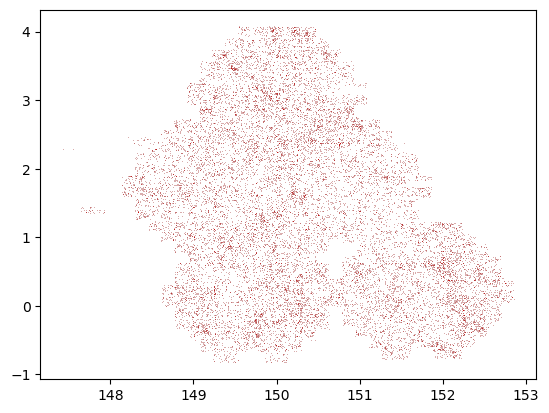

In [17]:
# PLot sky location of the matched objects
from desiutil.plots import prepare_data, init_sky, plot_grid_map, plot_healpix_map, plot_sky_circles, plot_sky_binned



ax= init_sky()
p = ax.scatter(ax.projection_ra(cosmos['ra']),ax.projection_dec(cosmos['dec']),color='black',s=0.25, marker='.', linewidths=0)
p = ax.scatter(ax.projection_ra(target[ra][idx_tar]),ax.projection_dec(target[dec][idx_tar]),color='red',s=0.25, marker='.', linewidth=0)
plt.show()

plt.scatter(cosmos['ra'][matched],cosmos['dec'][matched],color='black',s=0.25, marker='.', linewidths=0)
plt.scatter(target[ra][idx_tar][matched],target[dec][idx_tar][matched],color='red',s=0.25, marker='.', linewidths=0)
plt.show()

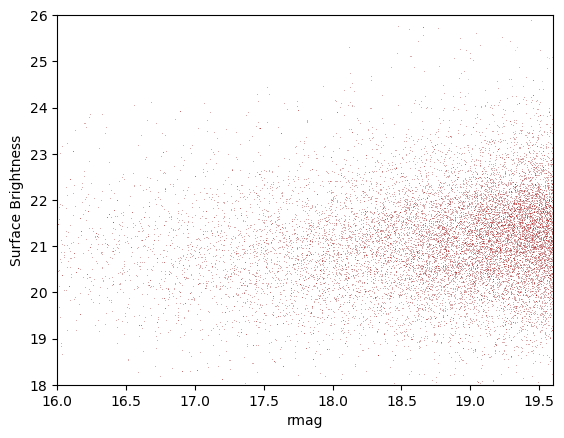

In [18]:
# Plot location on Magnitude SB plane

plt.scatter(rmag_cos,SB_cos,color='black',s=0.25, marker='.', linewidths=0)
plt.scatter(rmag_cos[matched],SB_cos[matched],color='red',s=0.25,marker='.',linewidth=0)
plt.xlim([16,19.6])
plt.ylim([18,26])
plt.xlabel('rmag')
plt.ylabel('Surface Brightness')
plt.show()

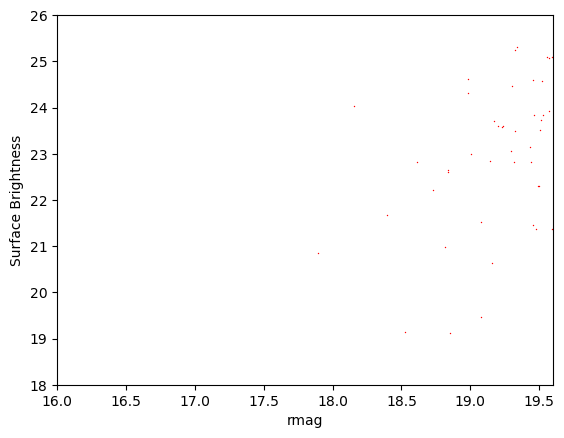

In [19]:
plt.scatter(rmag_cos[~matched],SB_cos[~matched],color='red',s=4.0,marker='.',linewidth=0)
plt.xlim([16,19.6])
plt.ylim([18,26])
plt.xlabel('rmag')
plt.ylabel('Surface Brightness')
plt.show()

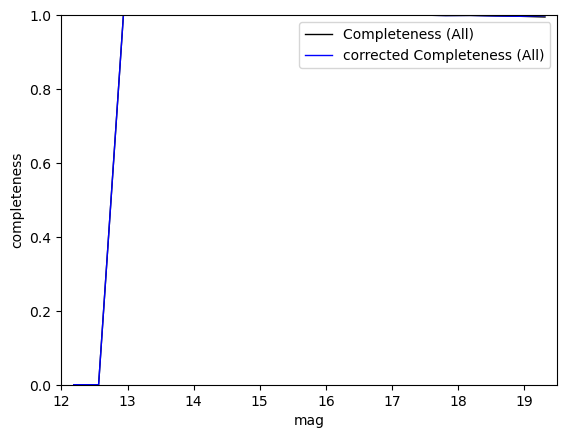

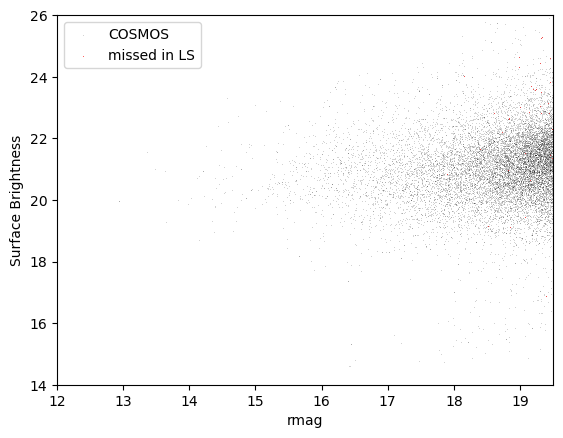

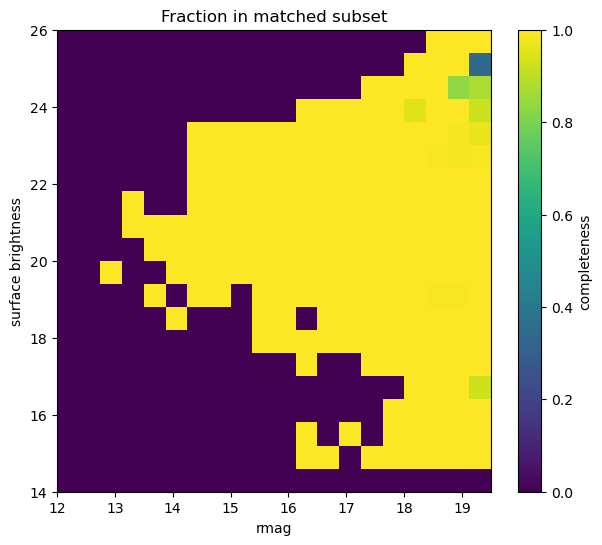

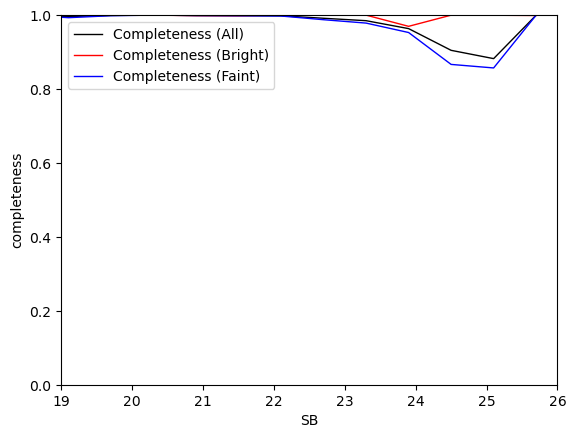

In [20]:
# Over a restricted part of this plane tabulated the matched fraction

mask=((SB_cos>10) & (SB_cos<30) &  (rmag_cos<19.5) )
#x=rmag[idx_tar][mask]
x=rmag_cos[mask]
y=SB_cos[mask]
rmatch=matched[mask]
nbins=20
xedges = np.linspace(12, 19.5, nbins+1)
yedges = np.linspace(14, 26, nbins+1)


#Also plot 1_D versions to see if much dependence on magnitude
magcenters=(xedges[1:]+xedges[:-1])/2.0

Hist_total, _ = np.histogram(x, bins=xedges)
Hist_matched, _ = np.histogram(x[rmatch], bins=xedges)
fraction_all = Hist_matched / (Hist_total+0.001)
plt.plot(magcenters, fraction_all, color='black', lw=1, label='Completeness (All)')


np.savetxt('out.txt', np.column_stack((magcenters, 100.0*(1.0-fraction_all), Hist_total-Hist_matched)),fmt=["%.2f", "%.3f", "%i"])

mask=~matched & (cosmos['rmag']<19.5) & (cosmos['rmag']>18) & (SB_cos>24)
np.savetxt('john.txt', np.column_stack((cosmos['rmag'][mask],cosmos['ra'][mask],cosmos['dec'][mask],SB_cos[mask])),fmt=["%.2f","%.5f","%.5f","%.2f"])




correction=1.0+0.0*fraction_all # set default correction to 1.0
correction[nbins-1]=np.median(fraction_all[nbins-4:nbins-2])/fraction_all[nbins-1]  #Correction factor for drop in final bin
plt.plot(magcenters, fraction_all*correction, color='blue', lw=1, label='corrected Completeness (All)')
plt.ylim([0.0,1.0])
plt.xlim([12,19.5])
plt.xlabel('mag')
plt.ylabel('completeness')
plt.legend()
plt.show()


# Plot the missed objects
plt.scatter(x,y,color='black',s=0.25,marker='.',linewidth=0,label='COSMOS')
plt.scatter(x[~rmatch],y[~rmatch],color='red',s=1.0,marker='.',linewidth=0,label='missed in LS')
plt.xlim([12,19.5])
plt.ylim([14,26])
plt.xlabel('rmag')
plt.ylabel('Surface Brightness')
plt.legend()
plt.show()

# Total counts per 2D bin
H_total, _, _ = np.histogram2d(x, y, bins=[xedges, yedges])

# Counts in masked subset per 2D bin
H_matched, _, _ = np.histogram2d(x[rmatch], y[rmatch], bins=[xedges, yedges])

# Compute fraction; avoid division by zero
fraction = H_matched / (H_total+0.001)
# Appply correction factor
#fraction = fraction * correction[:, None]

# Plot with pcolormesh (note transpose: histogram2d returns [xbin, ybin])
fig, ax = plt.subplots(figsize=(7, 6))
mesh = ax.pcolormesh(xedges, yedges, fraction.T, cmap='viridis', shading='auto', vmin=0.0, vmax=1.0)
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('completeness')

ax.set_xlabel('rmag')
ax.set_ylabel('surface brightness')
ax.set_title('Fraction in matched subset')
plt.show()
np.savez('sdata/Completeness_SB_ns.npz', H=fraction, xedges=xedges, yedges=yedges)


#Also plot 1_D versions to see if much dependence on magnitude
centers=(yedges[1:]+yedges[:-1])/2.0


Hist_total, _ = np.histogram(y, bins=yedges)
Hist_matched, _ = np.histogram(y[rmatch], bins=yedges)
fraction_all = Hist_matched / (Hist_total+0.001)
plt.plot(centers, fraction_all, color='black', lw=1, label='Completeness (All)')


bright=(x>17.5) & (x<18.5)
brightmatch = bright & rmatch
Hist_total, _ = np.histogram(y[bright], bins=yedges)
Hist_matched, _ = np.histogram(y[brightmatch], bins=yedges)
fraction_all = Hist_matched / (Hist_total+0.001)
plt.plot(centers, fraction_all, color='red', lw=1, label='Completeness (Bright)')

faint=(x>18.5) & (x<19.5)
faintmatch = faint & rmatch
Hist_total, _ = np.histogram(y[faint], bins=yedges)
Hist_matched, _ = np.histogram(y[faintmatch], bins=yedges)
fraction_all = Hist_matched / (Hist_total+0.001)
plt.plot(centers, fraction_all, color='blue', lw=1, label='Completeness (Faint)')


plt.ylim([0.0,1.0])
plt.xlim([19,26])
plt.xlabel('SB')
plt.ylabel('completeness')
plt.legend()
plt.show()



In [21]:
#cosmos.info('stats')

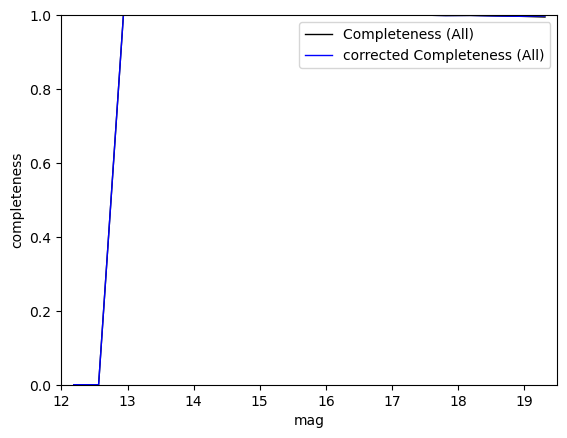

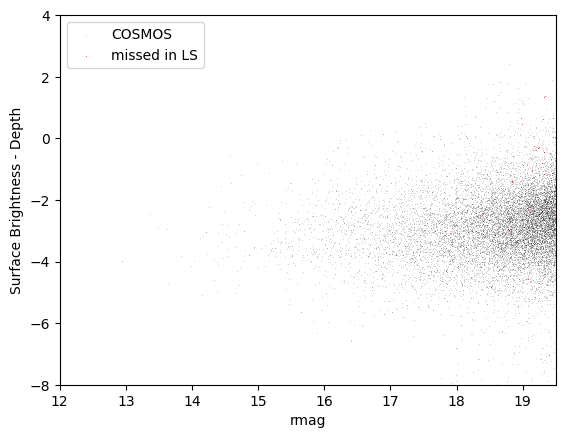

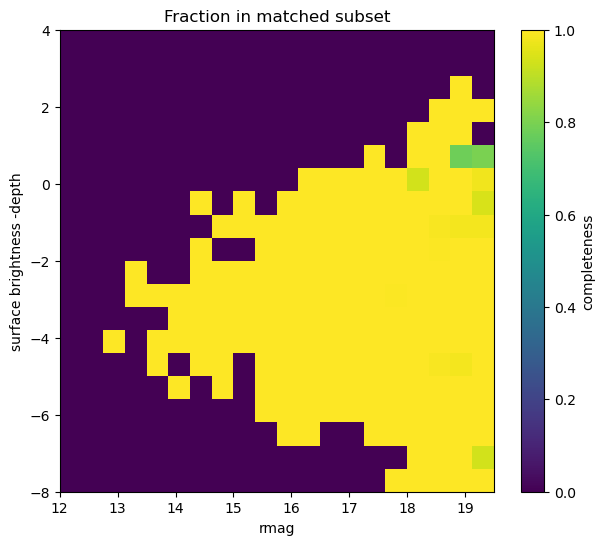

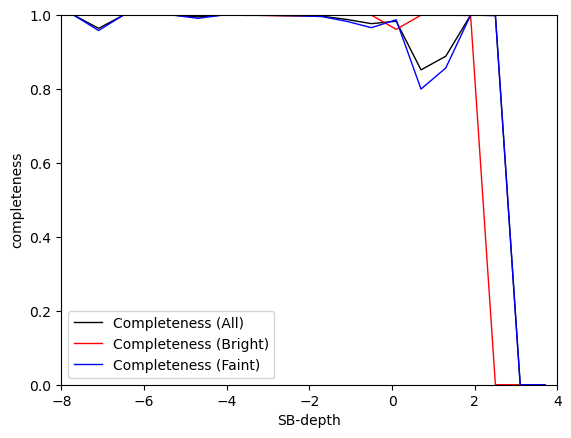

In [22]:
# Repeat but now in the mag versus SB-depth plane

SBminusdepth=SB_cos-depth
mask=((SBminusdepth>-8) & (SBminusdepth<4) &  (rmag_cos<19.5) )
x=rmag_cos[mask]
y=SBminusdepth[mask]
rmatch=matched[mask]
nbins=20
xedges = np.linspace(12, 19.5, nbins+1)
yedges = np.linspace(-8.0, 4.0, nbins+1)


#Also plot 1_D versions to see if much dependence on magnitude
magcenters=(xedges[1:]+xedges[:-1])/2.0

Hist_total, _ = np.histogram(x, bins=xedges)
Hist_matched, _ = np.histogram(x[rmatch], bins=xedges)
fraction_all = Hist_matched / (Hist_total+0.001)
plt.plot(magcenters, fraction_all, color='black', lw=1, label='Completeness (All)')
correction=1.0+0.0*fraction_all # set default correction to 1.0
correction[nbins-1]=np.median(fraction_all[nbins-3:nbins-2])/fraction_all[nbins-1]  #Correction factor for drop in final bin
plt.plot(magcenters, fraction_all*correction, color='blue', lw=1, label='corrected Completeness (All)')
plt.ylim([0,1.0])
plt.xlim([12,19.5])
plt.xlabel('mag')
plt.ylabel('completeness')
plt.legend()
plt.show()



plt.scatter(x,y,color='black',s=0.25,marker='.',linewidth=0,label='COSMOS')
plt.scatter(x[~rmatch],y[~rmatch],color='red',s=1.0,marker='.',linewidth=0,label='missed in LS')
plt.xlim([12,19.5])
plt.ylim([-8.0,4.0])
plt.xlabel('rmag')
plt.ylabel('Surface Brightness - Depth')
plt.legend()
plt.show()
# Total counts per 2D bin
H_total, _, _ = np.histogram2d(x, y, bins=[xedges, yedges])

# Counts in masked subset per 2D bin
H_matched, _, _ = np.histogram2d(x[rmatch], y[rmatch], bins=[xedges, yedges])

# Compute fraction; avoid division by zero
fraction = H_matched / (H_total+0.001)
# Appply correction factor
#fraction = fraction * correction[:, None]

# Plot with pcolormesh (note transpose: histogram2d returns [xbin, ybin])
fig, ax = plt.subplots(figsize=(7, 6))
mesh = ax.pcolormesh(xedges, yedges, fraction.T, cmap='viridis', shading='auto', vmin=0.0, vmax=1.0)
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('completeness')

ax.set_xlabel('rmag')
ax.set_ylabel('surface brightness -depth')
ax.set_title('Fraction in matched subset')
plt.show()
np.savez('sdata/Completeness_SB-depth_ns.npz', H=fraction, xedges=xedges, yedges=yedges)

#Also plot 1_D versions to see if much dependence on magnitude
centers=(yedges[1:]+yedges[:-1])/2.0


Hist_total, _ = np.histogram(y, bins=yedges)
Hist_matched, _ = np.histogram(y[rmatch], bins=yedges)
fraction_all = Hist_matched / (Hist_total+0.001)
plt.plot(centers, fraction_all, color='black', lw=1, label='Completeness (All)')


bright=(x>17.5) & (x<18.5)
brightmatch = bright & rmatch
Hist_total, _ = np.histogram(y[bright], bins=yedges)
Hist_matched, _ = np.histogram(y[brightmatch], bins=yedges)
fraction_all = Hist_matched / (Hist_total+0.001)
plt.plot(centers, fraction_all, color='red', lw=1, label='Completeness (Bright)')

faint=(x>18.5) & (x<19.5)
faintmatch = faint & rmatch
Hist_total, _ = np.histogram(y[faint], bins=yedges)
Hist_matched, _ = np.histogram(y[faintmatch], bins=yedges)
fraction_all = Hist_matched / (Hist_total+0.001)
plt.plot(centers, fraction_all, color='blue', lw=1, label='Completeness (Faint)')


plt.ylim([0.0,1.0])
plt.xlim([-8.0,4.0])
plt.xlabel('SB-depth')
plt.ylabel('completeness')
plt.legend()
plt.show()


